In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
from xgboost import XGBClassifier
from scipy.signal import butter, filtfilt, find_peaks
from pathlib import Path

## 1. Ladda in tabellen

In [56]:
path = Path('/home/johnny/code/johnnylazoq/pulseIQ/raw_data/Data File/PPG-BP dataset.xlsx')
df = pd.read_excel(path, header=1)
df.head()

,Num.,subject_ID,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Hypertension,Diabetes,cerebral infarction,cerebrovascular disease
0,1,2,Female,45,152,63,161,89,97,27.268006,Stage 2 hypertension,NaN,NaN,NaN
1,2,3,Female,50,157,50,160,93,76,20.284799,Stage 2 hypertension,NaN,NaN,NaN
2,3,6,Female,47,150,47,101,71,79,20.888889,Normal,NaN,NaN,NaN
3,4,8,Male,45,172,65,136,93,87,21.971336,Prehypertension,NaN,NaN,NaN
4,5,9,Female,46,155,65,123,73,73,27.055151,Prehypertension,NaN,NaN,NaN


In [57]:
df1 = df.copy()

## 2. Signalbehandling: HR, HRV, arteriell styvhet\n\nAlla funktioner definieras i EN cell, i rätt ordning (`signal_filter` innan `calcular_features`).

In [58]:
SIGNALS_DIR = Path('/home/johnny/code/johnnylazoq/pulseIQ/raw_data/Data File/0_subject')
FS = 1000  # Hz

def load_segments(subject_id):
    """loads an individual 3 segments, returnsen list with 3 numpy-arrays (one per segment)."""
    return [np.loadtxt(SIGNALS_DIR / f"{subject_id}_{seg}.txt") for seg in (1, 2, 3)]

def signal_filter(signal, fs, low=0.7, high=3.5):
    """Bandpassfilter 0.7-3.5 Hz."""
    nyq = fs / 2                                    # Nyquistfrekvens = 500 Hz (halva samplingsfrekvensen)
    b, a = butter(3, [low/nyq, high/nyq], btype='band')  # designar ett Butterworth-bandpass av ordning 3
    return filtfilt(b, a, signal)                   # applicerar filtret fram OCH bak → ingen fasförskjutning

def calcular_features(senal, fs):
    """hr, hrv_sdnn och sdppg_ratio ur en PPG-signal."""
    senal_filtrada = signal_filter(senal, fs)
    picos, _ = find_peaks(senal_filtrada, distance=fs*0.4)
    if len(picos) < 2:
        return {"hr": np.nan, "hrv_sdnn": np.nan, "sdppg_ratio": np.nan}
    intervalos = np.diff(picos) / fs
    hr = 60 / np.mean(intervalos)
    hrv_sdnn = np.std(intervalos) * 1000
    d2 = np.gradient(np.gradient(senal_filtrada))
    ratios = []
    for i in range(len(picos) - 1):
        v = d2[picos[i]:picos[i+1]]
        if len(v) > 3 and v.max() != 0:
            ratios.append(v.min() / v.max())
    sdppg_ratio = np.mean(ratios) if ratios else np.nan
    return {"hr": hr, "hrv_sdnn": hrv_sdnn, "sdppg_ratio": sdppg_ratio}

In [59]:
feature_rows = []
for subject_id in df1["subject_ID"]:
    sid = int(subject_id)
    try:
        segment_feats = [calcular_features(seg, FS) for seg in load_segments(sid)]
        mean_feats = {
            key: np.nanmean([f[key] for f in segment_feats])
            for key in ("hr", "hrv_sdnn", "sdppg_ratio")
        }
    except FileNotFoundError:
        mean_feats = {"hr": np.nan, "hrv_sdnn": np.nan, "sdppg_ratio": np.nan}
    feature_rows.append(mean_feats)

features_df = pd.DataFrame(feature_rows, index=df1.index)
df1 = pd.concat([df1, features_df], axis=1)

In [60]:
df1[["subject_ID", "hr", "hrv_sdnn", "sdppg_ratio"]].head()

,subject_ID,hr,hrv_sdnn,sdppg_ratio
0,2,95.115439,6.000000,-1.279236
1,3,78.327070,26.666667,-1.384622
2,6,74.090809,21.500000,-1.061490
3,8,90.697606,14.500000,-1.349119
4,9,85.898815,5.333333,-1.192647


In [61]:
df1.head(3)

,Num.,subject_ID,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Hypertension,Diabetes,cerebral infarction,cerebrovascular disease,hr,hrv_sdnn,sdppg_ratio
0,1,2,Female,45,152,63,161,89,97,27.268006,Stage 2 hypertension,NaN,NaN,NaN,95.115439,6.000000,-1.279236
1,2,3,Female,50,157,50,160,93,76,20.284799,Stage 2 hypertension,NaN,NaN,NaN,78.327070,26.666667,-1.384622
2,3,6,Female,47,150,47,101,71,79,20.888889,Normal,NaN,NaN,NaN,74.090809,21.500000,-1.061490


In [62]:
df1[["hr", "hrv_sdnn", "sdppg_ratio"]].describe()

,hr,hrv_sdnn,sdppg_ratio
count,219.000000,219.000000,219.000000
mean,78.966089,26.359789,-1.294008
std,10.684040,32.935129,0.167326
min,53.914810,0.000000,-1.981113
25%,71.804320,4.833333,-1.393487
50%,78.006596,11.594213,-1.267510
75%,86.447269,40.000000,-1.181696
max,116.671396,160.166667,-0.901281


In [63]:
(df1["hrv_sdnn"] == 0).sum()

np.int64(36)

In [64]:
noll = df1[df1["hrv_sdnn"] == 0]
noll[["subject_ID", "hr", "hrv_sdnn", "sdppg_ratio"]].head(10)

,subject_ID,hr,hrv_sdnn,sdppg_ratio
9,14,66.631858,0.0,-1.179674
20,26,74.584975,0.0,-1.228210
32,45,59.603133,0.0,-1.108961
39,54,74.684867,0.0,-1.320727
47,63,64.155010,0.0,-1.294252
51,67,66.693980,0.0,-1.269487
62,93,75.931659,0.0,-1.158043
66,98,74.711161,0.0,-1.223448
79,114,68.342469,0.0,-1.024215
91,130,71.745382,0.0,-1.245584


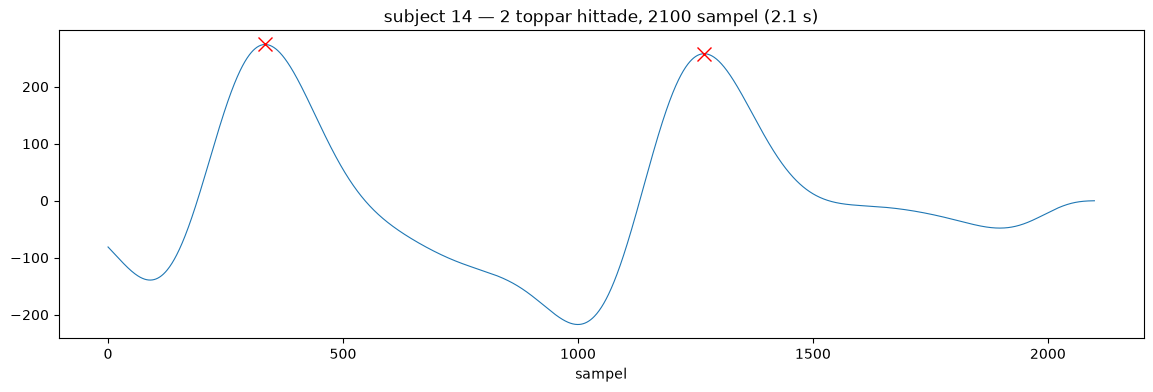

In [65]:
import matplotlib.pyplot as plt

sid = 14                                    # en av de drabbade
seg = load_segments(sid)[0]                 # första segmentet
filt = signal_filter(seg, FS)
picos, _ = find_peaks(filt, distance=FS*0.4)

plt.figure(figsize=(14, 4))
plt.plot(filt, linewidth=0.8)
plt.plot(picos, filt[picos], "rx", markersize=10)   # markera topparna
plt.title(f"subject {sid} — {len(picos)} toppar hittade, {len(seg)} sampel ({len(seg)/FS:.1f} s)")
plt.xlabel("sampel")
plt.show()

In [66]:
df1.loc[df1["hrv_sdnn"] == 0, "hrv_sdnn"] = np.nan
df1["hrv_sdnn"].isna().sum()     # ska bli 36
df1[["hr", "hrv_sdnn", "sdppg_ratio"]].describe()

,hr,hrv_sdnn,sdppg_ratio
count,219.000000,183.000000,219.000000
mean,78.966089,31.545321,-1.294008
std,10.684040,33.686870,0.167326
min,53.914810,0.166667,-1.981113
25%,71.804320,9.173316,-1.393487
50%,78.006596,14.500000,-1.267510
75%,86.447269,53.333333,-1.181696
max,116.671396,160.166667,-0.901281


## 4. Rensa datan

In [9]:
df1 = df.drop(columns=['Num.', 'subject_ID'])
df1['Diabetes'] = df1['Diabetes'].replace('Type 2 Diabetes', 'Diabetes')
df1['Diabetes'].value_counts()

Diabetes
Diabetes    38
Name: count, dtype: int64

In [67]:
df1

,Num.,subject_ID,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Hypertension,Diabetes,cerebral infarction,cerebrovascular disease,hr,hrv_sdnn,sdppg_ratio
0,1,2,Female,45,152,63,161,89,97,27.268006,Stage 2 hypertension,NaN,NaN,NaN,95.115439,6.000000,-1.279236
1,2,3,Female,50,157,50,160,93,76,20.284799,Stage 2 hypertension,NaN,NaN,NaN,78.327070,26.666667,-1.384622
2,3,6,Female,47,150,47,101,71,79,20.888889,Normal,NaN,NaN,NaN,74.090809,21.500000,-1.061490
3,4,8,Male,45,172,65,136,93,87,21.971336,Prehypertension,NaN,NaN,NaN,90.697606,14.500000,-1.349119
4,5,9,Female,46,155,65,123,73,73,27.055151,Prehypertension,NaN,NaN,NaN,85.898815,5.333333,-1.192647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,215,415,Male,24,180,70,111,70,77,21.604938,Normal,NaN,NaN,NaN,84.023700,9.500000,-1.411997
215,216,416,Female,25,156,47,93,57,79,19.312952,Normal,NaN,NaN,NaN,84.695058,12.666667,-1.587479
216,217,417,Male,25,176,55,120,69,72,17.755682,Prehypertension,NaN,NaN,NaN,101.225640,151.393114,-1.476814
217,218,418,Male,25,173,63,106,69,67,21.049818,Normal,NaN,NaN,NaN,73.387075,56.333333,-1.591910


In [68]:
df1.loc[df1['hrv_sdnn'] == 0, 'hrv_sdnn'] = np.nan

df1['Diabetes'] = df1['Diabetes'].replace('Type 2 Diabetes', 'Diabetes')
df1['Diabetes'] = df1['Diabetes'].map({np.nan: 0, 'Diabetes': 1})
df1['Sex(M/F)'] = df1['Sex(M/F)'].map({'Female': 0, 'Male': 1})

df1 = df1.drop(columns=['Num.', 'subject_ID'])
df1.head()

,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Hypertension,Diabetes,cerebral infarction,cerebrovascular disease,hr,hrv_sdnn,sdppg_ratio
0,0,45,152,63,161,89,97,27.268006,Stage 2 hypertension,0,NaN,NaN,95.115439,6.000000,-1.279236
1,0,50,157,50,160,93,76,20.284799,Stage 2 hypertension,0,NaN,NaN,78.327070,26.666667,-1.384622
2,0,47,150,47,101,71,79,20.888889,Normal,0,NaN,NaN,74.090809,21.500000,-1.061490
3,1,45,172,65,136,93,87,21.971336,Prehypertension,0,NaN,NaN,90.697606,14.500000,-1.349119
4,0,46,155,65,123,73,73,27.055151,Prehypertension,0,NaN,NaN,85.898815,5.333333,-1.192647


In [69]:
df_diabetes = df1.drop(columns=['Hypertension', 'cerebral infarction', 'cerebrovascular disease'])
df_diabetes.dtypes

Sex(M/F)                            int64
Age(year)                           int64
Height(cm)                          int64
Weight(kg)                          int64
Systolic Blood Pressure(mmHg)       int64
Diastolic Blood Pressure(mmHg)      int64
Heart Rate(b/m)                     int64
BMI(kg/m^2)                       float64
Diabetes                            int64
hr                                float64
hrv_sdnn                          float64
sdppg_ratio                       float64
dtype: object

## 5. Förbered för diabetes-modellen

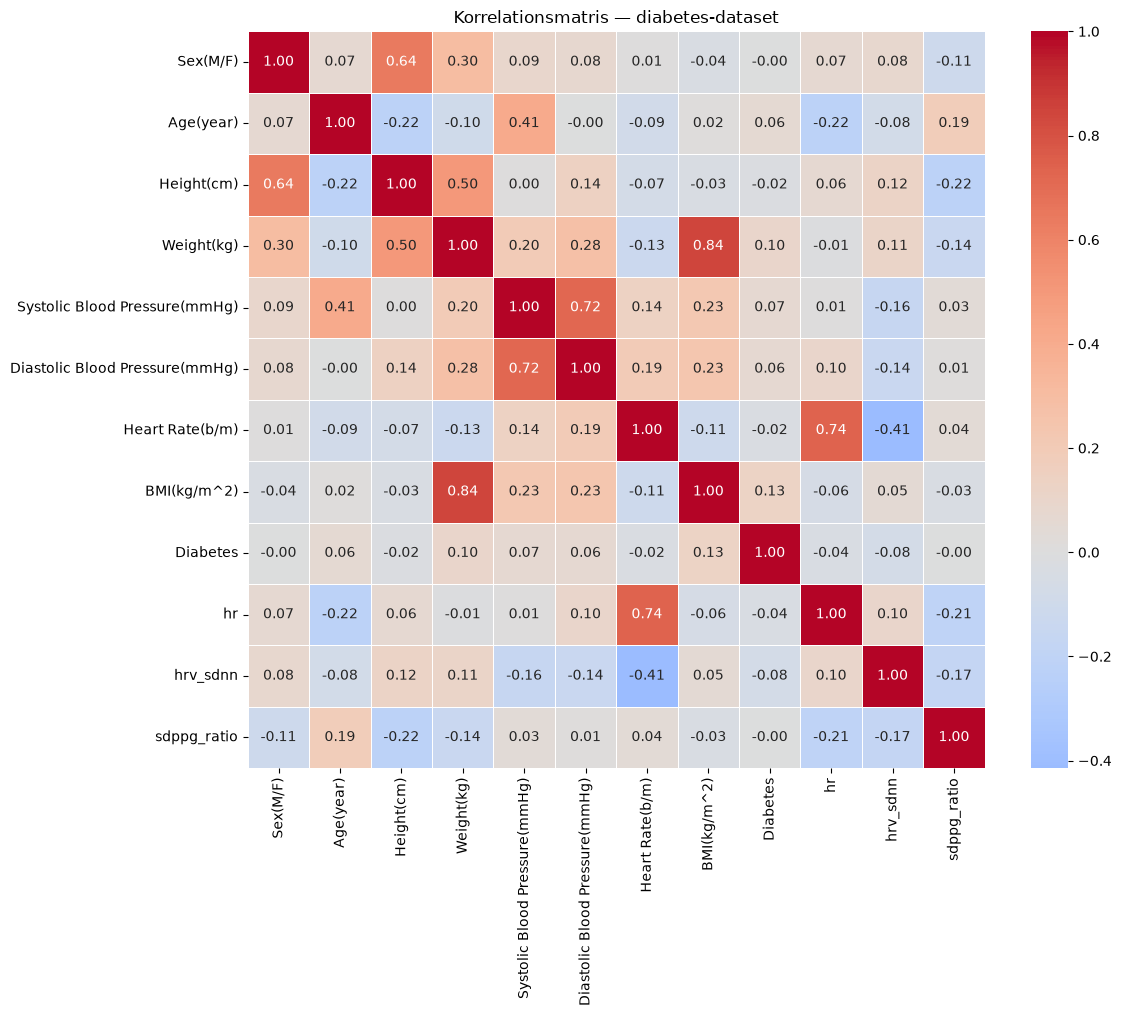

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(df_diabetes.corr(),      # NaN hanteras automatiskt (parvis)
            annot=True,               # skriv ut korrelationsvärdena
            fmt='.2f',                # två decimaler
            cmap='coolwarm',          # blå = negativ, röd = positiv
            center=0,                 # noll i mitten av färgskalan
            square=True,
            linewidths=0.5)
plt.title('Correlatoin matrix — diabetes-dataset')
plt.tight_layout()
plt.show()

In [74]:
df_diabetes = df1.drop(columns=['Hypertension', 'cerebral infarction', 'cerebrovascular disease'])

# Fyll ev. NaN i signal-features (trasiga signaler) med medianen,
# annars kraschar LogisticRegression
df_diabetes = df_diabetes.fillna(df_diabetes.median(numeric_only=True))

In [75]:
df_diabetes

,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Diabetes,hr,hrv_sdnn,sdppg_ratio
0,0,45,152,63,161,89,97,27.268006,0,95.115439,6.000000,-1.279236
1,0,50,157,50,160,93,76,20.284799,0,78.327070,26.666667,-1.384622
2,0,47,150,47,101,71,79,20.888889,0,74.090809,21.500000,-1.061490
3,1,45,172,65,136,93,87,21.971336,0,90.697606,14.500000,-1.349119
4,0,46,155,65,123,73,73,27.055151,0,85.898815,5.333333,-1.192647
...,...,...,...,...,...,...,...,...,...,...,...,...
214,1,24,180,70,111,70,77,21.604938,0,84.023700,9.500000,-1.411997
215,0,25,156,47,93,57,79,19.312952,0,84.695058,12.666667,-1.587479
216,1,25,176,55,120,69,72,17.755682,0,101.225640,151.393114,-1.476814
217,1,25,173,63,106,69,67,21.049818,0,73.387075,56.333333,-1.591910


In [ ]:
X_

In [ ]:
#from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler().set_output(transform='pandas')
#x_scaled = scaler.fit_transform(df_diabetes.drop(columns=['Sex(M/F)', 'Diabetes']))
#y_diabetes = df_diabetes['Diabetes']
#X_diabetes = pd.concat([x_scaled, df_diabetes['Sex(M/F)']], axis=1)

In [ ]:
#sns.heatmap(pd.concat([X_diabetes, y_diabetes], axis=1).corr(), annot=True)

ValueError: could not convert string to float: 'Female'

## 6. Logistic Regression baseline

In [101]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold

X = df_diabetes.drop(columns=['Diabetes'])
y = df_diabetes['Diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y)

In [98]:
X

,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),hr,hrv_sdnn,sdppg_ratio
0,0,45,152,63,161,89,97,27.268006,95.115439,6.000000,-1.279236
1,0,50,157,50,160,93,76,20.284799,78.327070,26.666667,-1.384622
2,0,47,150,47,101,71,79,20.888889,74.090809,21.500000,-1.061490
3,1,45,172,65,136,93,87,21.971336,90.697606,14.500000,-1.349119
4,0,46,155,65,123,73,73,27.055151,85.898815,5.333333,-1.192647
...,...,...,...,...,...,...,...,...,...,...,...
214,1,24,180,70,111,70,77,21.604938,84.023700,9.500000,-1.411997
215,0,25,156,47,93,57,79,19.312952,84.695058,12.666667,-1.587479
216,1,25,176,55,120,69,72,17.755682,101.225640,151.393114,-1.476814
217,1,25,173,63,106,69,67,21.049818,73.387075,56.333333,-1.591910


In [ ]:


model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

cv = cross_validate(model, X_train, y_train, cv=5, scoring=['roc_auc'])
cv['test_roc_auc'].mean()

np.float64(0.5137931034482758)

## 7. XGBoost (korsvalidering)

In [81]:
X_train.head()

,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),hr,hrv_sdnn,sdppg_ratio
197,1,56,170,74,143,82,60,25.605536,68.282826,90.333333,-1.058475
146,1,30,196,103,121,78,60,26.811745,92.802687,87.333333,-1.490741
127,0,32,151,61,101,70,79,26.753213,86.948348,62.349349,-1.135253
99,0,74,153,40,148,69,92,17.087445,88.614872,5.333333,-1.363616
23,1,80,170,70,173,90,73,24.221453,73.924699,8.000000,-1.322665


In [100]:
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5,)
scores = []
for train_index, test_index in skf.split(X, y):
    X_tr, y_tr = X.iloc[train_index], y.iloc[train_index]
    X_te, y_te = X.iloc[test_index], y.iloc[test_index]
    m = XGBClassifier(eval_metric='logloss')
    m.fit(X_tr, y_tr)
    scores.append(roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]))
scores
np.mean(scores)

np.float64(0.4567004504504504)

In [ ]:
np.float64(0.4567004504504504)
np.float64(0.523546761046761)


In [84]:
m.feature_importances_

array([0.09844961, 0.10615224, 0.10647997, 0.09763218, 0.12281531,
       0.04401766, 0.08411465, 0.12105894, 0.03962001, 0.13191815,
       0.04774125], dtype=float32)

In [85]:
m.feature_names_in_


array(['Sex(M/F)', 'Age(year)', 'Height(cm)', 'Weight(kg)',
       'Systolic Blood Pressure(mmHg)', 'Diastolic Blood Pressure(mmHg)',
       'Heart Rate(b/m)', 'BMI(kg/m^2)', 'hr', 'hrv_sdnn', 'sdppg_ratio'],
      dtype='<U30')

In [94]:
data = pd.DataFrame({

    'features': m.feature_names_in_,
    'importance': m.feature_importances_
})
data.sort_values(by='importance', ascending=False)

,features,importance
9,hrv_sdnn,0.131918
4,Systolic Blood Pressure(mmHg),0.122815
7,BMI(kg/m^2),0.121059
2,Height(cm),0.106480
1,Age(year),0.106152
0,Sex(M/F),0.098450
3,Weight(kg),0.097632
6,Heart Rate(b/m),0.084115
10,sdppg_ratio,0.047741
5,Diastolic Blood Pressure(mmHg),0.044018


In [103]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier



def objective(trial):
    # clasificador
    classifier_name = trial.suggest_categorical('classifier', ['XGBClassifier']) #, 'LogisticRegression', 'RandomForestClassifier'

    if classifier_name == 'XGBClassifier':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'eval_metric': 'logloss',
            'random_state': 42,
            'n_jobs': -1
        }


    # Kfolds
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []

    X_arr = np.array(X)
    y_arr = np.array(y)

    for train_idx, val_idx in skf.split(X_arr, y_arr):
        X_train, X_test = X_arr[train_idx], X_arr[val_idx]
        y_train, y_test = y_arr[train_idx], y_arr[val_idx]

        #if classifier_name == 'XGBClassifier':
        model = XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        #elif classifier_name == 'LogisticRegression':
        #    model = LogisticRegression(**params)
        #    model.fit(X_train, y_train)
        #else:
        #    model = RandomForestClassifier(**params)
        #    model.fit(X_train, y_train)

        preds = model.predict_proba(X_test)
        score = roc_auc_score(y_test, preds[:,1])
        fold_scores.append(score)

    return np.mean(fold_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

print("Mejor ROC_AUC:", study.best_value)
print("Mejores parámetros:", study.best_params)


[I 2026-08-28 17:57:29,185] A new study created in memory with name: no-name-c971d5ef-dc89-4c98-88dc-7d75459da727
[I 2026-08-28 17:57:33,878] Trial 0 finished with value: 0.5778635778635779 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.13331946726948102, 'min_child_weight': 8, 'subsample': 0.8690323665062294, 'colsample_bytree': 0.7545295986571484, 'gamma': 0.737605439754764, 'reg_alpha': 0.5927974807993579, 'reg_lambda': 0.30253356279235927}. Best is trial 0 with value: 0.5778635778635779.
[I 2026-08-28 17:57:34,763] Trial 1 finished with value: 0.5442165379665379 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.024957366812472816, 'min_child_weight': 2, 'subsample': 0.8070263875762307, 'colsample_bytree': 0.8236408726917881, 'gamma': 6.95497844944997e-06, 'reg_alpha': 5.858654790629614e-05, 'reg_lambda': 4.444468311636792}. Best is trial 0 with value: 0.5778635778635779.
[

Mejor ROC_AUC: 0.6599259974259974
Mejores parámetros: {'classifier': 'XGBClassifier', 'n_estimators': 900, 'max_depth': 7, 'learning_rate': 0.9967725436120742, 'min_child_weight': 8, 'subsample': 0.9703687048047717, 'colsample_bytree': 0.5831888389395348, 'gamma': 7.317780005833876e-06, 'reg_alpha': 6.987762575658313e-07, 'reg_lambda': 0.0010664990642122378}
